# BELLA: Baseline Experimental Light-Learning AI

**Science/secular prototype for an optical AI receiver.**

Workflow: simulate/load intensity traces, run TDGSA, refine with physics-informed PyTorch, verify without hidden phase, and build an AI verifier feature vector.

Core claim: a recovered field is credible when it reproduces measured intensity, obeys the propagation model, conserves energy within tolerance, and remains stable under restarts/noise.

In [4]:
# ============================================================
# 1. Imports, device, and reproducibility
# ============================================================
import math
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except Exception as e:
    raise RuntimeError("Install PyTorch first: pip install torch") from e

seed = 7
np.random.seed(seed)
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("BELLA device:", device)

BELLA device: cpu


## Measurement model

We assume two intensity measurements:

- `I1`: intensity before or at low dispersion
- `I2`: intensity after a known dispersive element

The complex field is $E(t)=A(t)e^{i\phi(t)}$, but the detector measures only $I(t)=|E(t)|^2$.

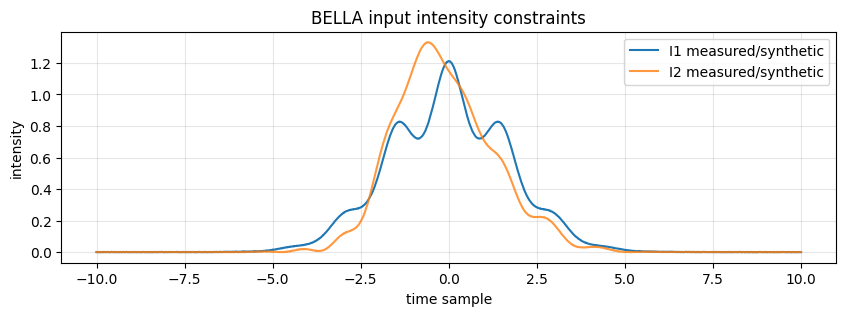

In [5]:
# ============================================================
# 2. Synthetic measurement generator
# Replace this section with real oscilloscope traces later.
# ============================================================
N = 2048
t = torch.linspace(-10, 10, N, device=device)
dt = float(t[1] - t[0])
freq = torch.fft.fftfreq(N, d=dt).to(device)
omega = 2 * math.pi * freq

# Simple dispersive propagation model.
beta2 = -0.85
L = 1.0
H = torch.exp(-0.5j * beta2 * L * omega**2)

# Hidden synthetic phase exists only for simulation diagnostics.
amp_true = torch.exp(-0.5 * (t / 2.4)**2) * (1.0 + 0.10 * torch.cos(4.0 * t))
amp_true = torch.clamp(amp_true, min=0.0)
phi_true = 0.12 * t**2 + 0.45 * torch.sin(0.7 * t)

E1_true = amp_true * torch.exp(1j * phi_true)
E2_true = torch.fft.ifft(torch.fft.fft(E1_true) * H)

noise = 0.002
I1_meas = torch.abs(E1_true)**2 + noise * torch.rand(N, device=device)
I2_meas = torch.abs(E2_true)**2 + noise * torch.rand(N, device=device)
I1_meas = torch.clamp(I1_meas, min=0.0)
I2_meas = torch.clamp(I2_meas, min=0.0)

plt.figure(figsize=(10, 3))
plt.plot(t.detach().cpu().numpy(), I1_meas.detach().cpu().numpy(), label="I1 measured/synthetic")
plt.plot(t.detach().cpu().numpy(), I2_meas.detach().cpu().numpy(), label="I2 measured/synthetic", alpha=0.8)
plt.title("BELLA input intensity constraints")
plt.xlabel("time sample")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

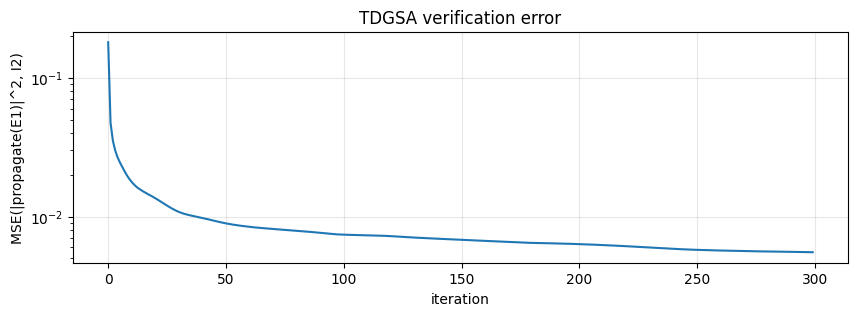

In [6]:
# ============================================================
# 3. TDGSA baseline: alternating intensity constraints
# ============================================================
def tdgsa(I1, I2, H, n_iter=300, seed=0):
    # Time-domain Gerchberg-Saxton style phase recovery.
    torch.manual_seed(seed)
    phase = 2 * math.pi * torch.rand_like(I1) - math.pi
    E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * phase)
    errors = []

    for _ in range(n_iter):
        E2 = torch.fft.ifft(torch.fft.fft(E1) * H)
        I2_pred = torch.abs(E2)**2
        errors.append(torch.mean((I2_pred - I2)**2).detach())

        E2 = torch.sqrt(I2 + 1e-12) * torch.exp(1j * torch.angle(E2))
        E1_back = torch.fft.ifft(torch.fft.fft(E2) * torch.conj(H))
        E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * torch.angle(E1_back))

    return E1, torch.stack(errors)

E1_gs, gs_errors = tdgsa(I1_meas, I2_meas, H, n_iter=300, seed=2)

plt.figure(figsize=(10, 3))
plt.semilogy(gs_errors.detach().cpu().numpy())
plt.title("TDGSA verification error")
plt.xlabel("iteration")
plt.ylabel("MSE(|propagate(E1)|^2, I2)")
plt.grid(True, alpha=0.3)
plt.show()

final total loss: 0.005295633338391781
final intensity loss: 0.0013162625255063176


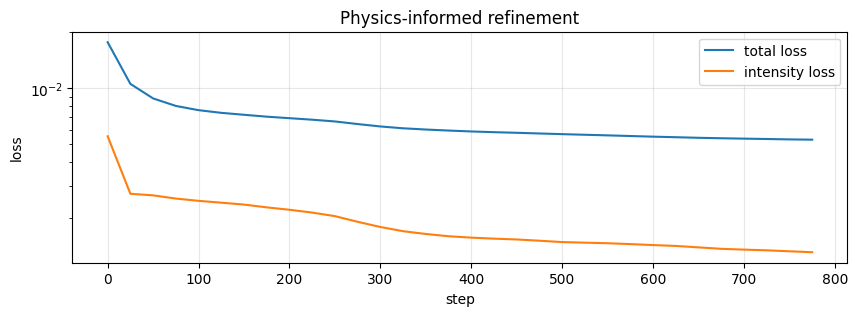

In [7]:
# ============================================================
# 4. Physics-informed PyTorch refinement
# ============================================================
phase = torch.nn.Parameter(torch.angle(E1_gs).detach().clone())
optimizer = torch.optim.Adam([phase], lr=0.025)

loss_history = []
for step in range(800):
    E1 = torch.sqrt(I1_meas + 1e-12) * torch.exp(1j * phase)
    E2 = torch.fft.ifft(torch.fft.fft(E1) * H)
    I2_pred = torch.abs(E2)**2

    intensity_loss = torch.mean((I2_pred - I2_meas)**2)
    energy_loss = (torch.sum(torch.abs(E1)**2) - torch.sum(torch.abs(E2)**2)).pow(2) / (N**2)
    phase_smooth_loss = torch.mean((phase[1:] - phase[:-1])**2)
    group_delay_smooth_loss = torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)

    loss = intensity_loss + 0.001 * energy_loss + 0.0005 * phase_smooth_loss + 0.0005 * group_delay_smooth_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 25 == 0:
        loss_history.append([step, float(loss.detach()), float(intensity_loss.detach()), float(energy_loss.detach()), float(phase_smooth_loss.detach())])

loss_history = np.array(loss_history)
print("final total loss:", loss_history[-1, 1])
print("final intensity loss:", loss_history[-1, 2])

plt.figure(figsize=(10, 3))
plt.semilogy(loss_history[:, 0], loss_history[:, 1], label="total loss")
plt.semilogy(loss_history[:, 0], loss_history[:, 2], label="intensity loss")
plt.title("Physics-informed refinement")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
# ============================================================
# 5. Unsupervised physics verification
# This is the main result for real experiments.
# ============================================================
with torch.no_grad():
    E1_rec = torch.sqrt(I1_meas + 1e-12) * torch.exp(1j * phase)
    E2_rec = torch.fft.ifft(torch.fft.fft(E1_rec) * H)
    I2_rec = torch.abs(E2_rec)**2

    intensity_mse = torch.mean((I2_rec - I2_meas)**2)
    intensity_corr = torch.corrcoef(torch.stack([I2_rec, I2_meas]))[0, 1]
    energy_error = torch.abs(torch.sum(torch.abs(E1_rec)**2) - torch.sum(torch.abs(E2_rec)**2)) / torch.sum(torch.abs(E1_rec)**2)
    phase_smoothness = torch.mean((phase[1:] - phase[:-1])**2)
    group_delay_smoothness = torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)

features = torch.tensor([
    float(intensity_mse),
    float(1 - intensity_corr),
    float(energy_error),
    float(phase_smoothness),
    float(group_delay_smoothness),
    float(gs_errors[-1]),
    float(loss_history[-1, 1]),
], device=device)

feature_names = [
    "intensity_mse",
    "1_minus_intensity_corr",
    "energy_error",
    "phase_smoothness",
    "group_delay_smoothness",
    "tdgsa_final_error",
    "final_physics_loss",
]

print("BELLA physics verification features:")
for name, value in zip(feature_names, features.detach().cpu().numpy()):
    print(f"  {name:28s} {value:.6e}")

passed = (
    intensity_mse < 5e-4 and
    intensity_corr > 0.98 and
    energy_error < 1e-5 and
    phase_smoothness < 2.0
)
print("\nUNSUPERVISED VERIFICATION:", "PASS" if passed else "CHECK / NOT PASS")

BELLA physics verification features:
  intensity_mse                1.308933e-03
  1_minus_intensity_corr       3.411293e-03
  energy_error                 2.082541e-07
  phase_smoothness             2.349216e+00
  group_delay_smoothness       5.605618e+00
  tdgsa_final_error            5.528201e-03
  final_physics_loss           5.295633e-03

UNSUPERVISED VERIFICATION: CHECK / NOT PASS


In [9]:
# ============================================================
# 6. AI verifier scaffold
# Train this later on many traces/restarts/noise levels.
# ============================================================
class BellaVerifier(torch.nn.Module):
    def __init__(self, n_features=7):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_features, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 8),
            torch.nn.ReLU(),
            torch.nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.net(x)

verifier = BellaVerifier(n_features=len(features)).to(device)

with torch.no_grad():
    logits = verifier(features[None, :])
    confidence_placeholder = torch.sigmoid(logits).item()
print("Untrained verifier placeholder confidence:", confidence_placeholder)
print("Train verifier later using PASS/CHECK labels from many simulated and experimental runs.")

Untrained verifier placeholder confidence: 0.4700879156589508
Train verifier later using PASS/CHECK labels from many simulated and experimental runs.


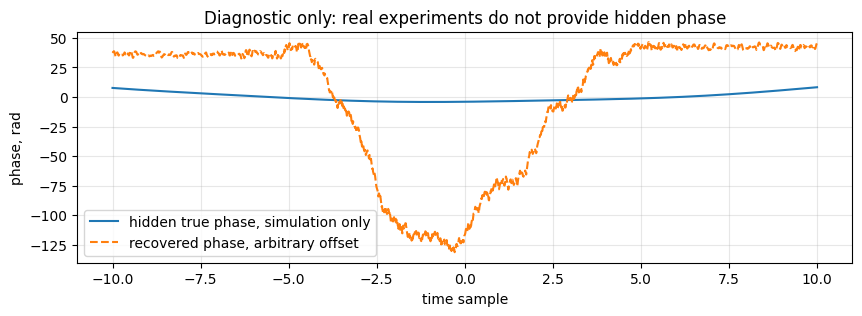

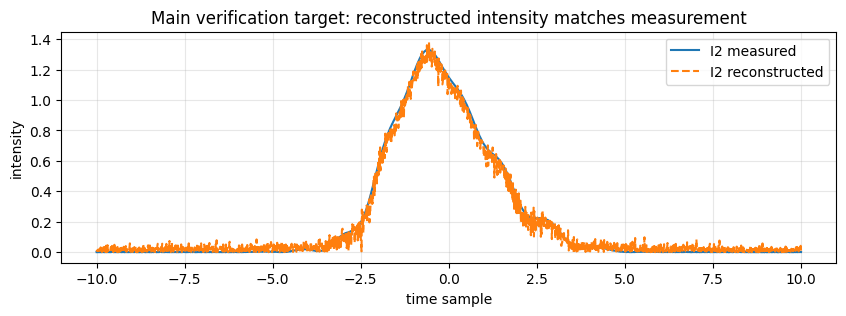

In [10]:
# ============================================================
# 7. Diagnostic plots
# Hidden phase comparison is only for simulation debugging.
# ============================================================
phase_rec_np = np.unwrap(phase.detach().cpu().numpy())
phase_true_np = np.unwrap(phi_true.detach().cpu().numpy())
phase_rec_aligned = phase_rec_np - np.mean(phase_rec_np)
phase_true_aligned = phase_true_np - np.mean(phase_true_np)

t_np = t.detach().cpu().numpy()

plt.figure(figsize=(10, 3))
plt.plot(t_np, phase_true_aligned, label="hidden true phase, simulation only")
plt.plot(t_np, phase_rec_aligned, "--", label="recovered phase, arbitrary offset")
plt.title("Diagnostic only: real experiments do not provide hidden phase")
plt.xlabel("time sample")
plt.ylabel("phase, rad")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t_np, I2_meas.detach().cpu().numpy(), label="I2 measured")
plt.plot(t_np, I2_rec.detach().cpu().numpy(), "--", label="I2 reconstructed")
plt.title("Main verification target: reconstructed intensity matches measurement")
plt.xlabel("time sample")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## How to take real measurements

1. Split the optical pulse into two paths.
2. Path A: measure `I1` with photodiode + oscilloscope.
3. Path B: send through a known dispersive element, then measure `I2`.
4. Record sampling rate, time step, wavelength band, fiber length, and dispersion parameter.
5. Subtract dark offset from each trace.
6. Clip negative values after baseline correction.
7. Normalize each trace by total energy or max value.
8. Resample `I1` and `I2` to the same number of points.
9. Replace the synthetic `I1_meas` and `I2_meas` tensors in this notebook.
10. Run TDGSA, physics-informed refinement, and BELLA verification.

Do not claim exact phase truth unless you have an independent phase measurement.